# Import libraries

In [1]:
!pip install -q seqeval torchinfo evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00


In [2]:
import os
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# Download dataset

In [4]:
dataset = load_dataset("phucdev/PhoNER_COVID19", "syllable")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

syllable/train-00000-of-00001.parquet:   0%|          | 0.00/367k [00:00<?, ?B/s]

syllable/validation-00000-of-00001.parqu(…):   0%|          | 0.00/159k [00:00<?, ?B/s]

syllable/test-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5027 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

# Load tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base", use_fast=True)
print(type(tokenizer), tokenizer.is_fast)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

<class 'transformers.models.xlm_roberta.tokenization_xlm_roberta.XLMRobertaTokenizer'> True


In [6]:
print(tokenizer.vocab_size)

250002


# Preprocess data

In [7]:
# Bộ dataset cần ép về chuẩn NFC để tokenizers mới không bị lỗi
def preprocess(word_list):
    cleaned_words = [unicodedata.normalize('NFC', w) for w in word_list]
    return cleaned_words

clean_dataset = dataset.map(
    lambda x: {'words': preprocess(x['words'])},
    num_proc=8
)

# clean_dataset = dataset

Map (num_proc=8):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/3000 [00:00<?, ? examples/s]

# Measure dataset length

In [8]:
def get_length(examples):
    return {
        "length": [len(ids) for ids in examples["words"]]
    }

length_dataset = clean_dataset.map(
    get_length,
    batched=True,
    num_proc=8,
    remove_columns=['words', 'tags']
)

Map (num_proc=8):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/3000 [00:00<?, ? examples/s]

--- Statistics for train ---
Mean: 33.33 | Max: 186 | p95: 64 | p99: 84

--- Statistics for validation ---
Mean: 35.66 | Max: 182 | p95: 68 | p99: 92

--- Statistics for test ---
Mean: 36.12 | Max: 185 | p95: 68 | p99: 93



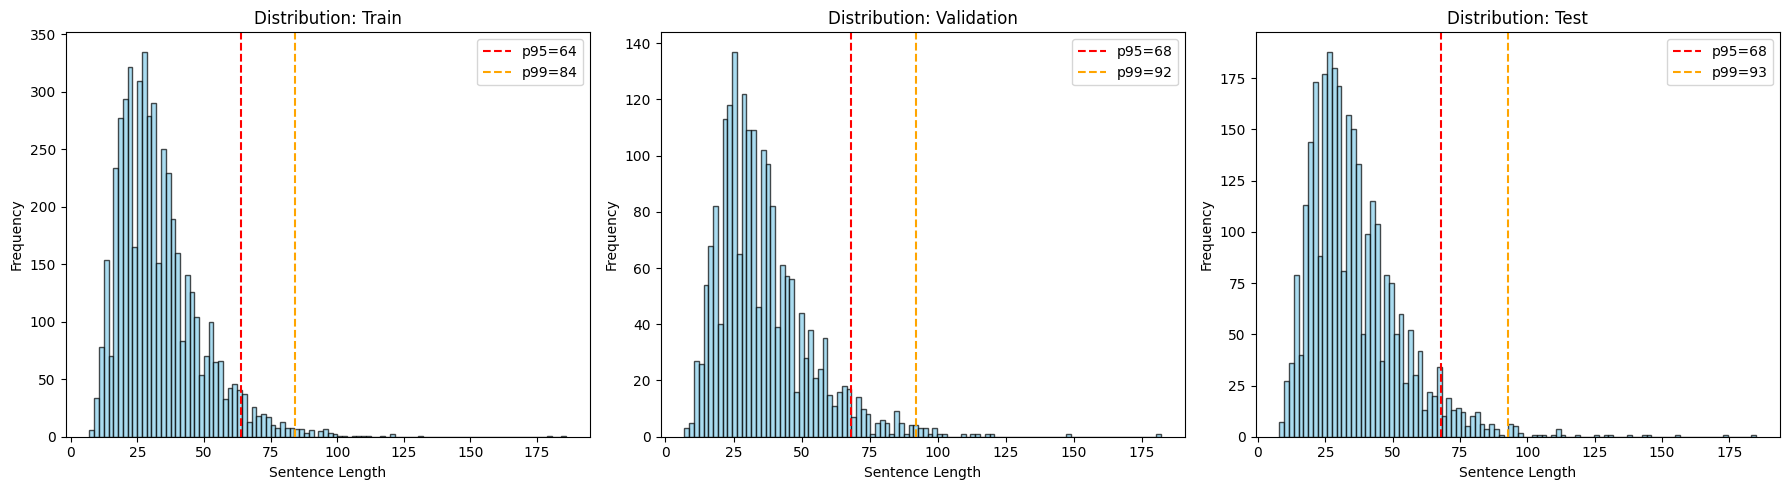

In [9]:
dataset_stats = {}
splits = ["train", "validation", "test"]

# Thiết lập figure cho plotting (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split in enumerate(splits):
    # 1. Trích xuất độ dài
    lengths = np.array(length_dataset[split]["length"])

    # 2. Tính toán các chỉ số
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_val = int(lengths.max())
    mean_val = lengths.mean()

    # 3. Lưu vào dictionary
    dataset_stats[split] = {
        "p95": p95,
        "p99": p99,
        "max_len": max_val,
        "mean": mean_val
    }

    # 4. In thông tin ra màn hình
    print(f"--- Statistics for {split} ---")
    print(f"Mean: {mean_val:.2f} | Max: {max_val} | p95: {p95} | p99: {p99}\n")

    # 5. Vẽ biểu đồ histogram lên subplot tương ứng
    axes[i].hist(lengths, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(p95, color='red', linestyle='--', label=f'p95={p95}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'p99={p99}')

    axes[i].set_title(f'Distribution: {split.capitalize()}')
    axes[i].set_xlabel('Sentence Length')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Tokenize dataset

In [10]:
unique_tags = set()
for tags in clean_dataset['train']['tags']:
    unique_tags.update(tags)

unique_tags = sorted(list(unique_tags))

label2idx = {tag: i for i, tag in enumerate(unique_tags)}
idx2label = {i: tag for i, tag in enumerate(unique_tags)}

IGNORE_INDEX = -100

print(f"Số lượng nhãn: {len(unique_tags)}")
print("IGNORE_INDEX:", IGNORE_INDEX)
print("label2idx:", label2idx)

Số lượng nhãn: 21
IGNORE_INDEX: -100
label2idx: {'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-GENDER': 12, 'I-JOB': 13, 'I-LOCATION': 14, 'I-NAME': 15, 'I-ORGANIZATION': 16, 'I-PATIENT_ID': 17, 'I-SYMPTOM_AND_DISEASE': 18, 'I-TRANSPORTATION': 19, 'O': 20}


In [11]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True,
        padding=False
    )

    all_labels = []

    for batch_index, tags in enumerate(examples["tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=batch_index)
        label_ids = []
        previous_word_id = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(IGNORE_INDEX)
            elif word_id != previous_word_id:
                label_ids.append(label2idx[tags[word_id]])
            else:
                label_ids.append(IGNORE_INDEX)
            previous_word_id = word_id

        all_labels.append(label_ids)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

tokenized_dataset = clean_dataset.map(
    tokenize_and_align_labels,
    num_proc=2,
    batched=True,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

In [12]:
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# Utils

In [13]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=IGNORE_INDEX
)

In [14]:
# Sử dụng hàm này để tránh cho shape của train_loss, eval_loss lệch nhau dẫn tới
# vẽ biểu đồ không chính xác

def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
def labels_from_predictions(predictions, labels):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [idx2label[p] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [idx2label[l] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    return true_labels, true_predictions

In [16]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    return {
        "f1": f1_score(true_labels, true_predictions),
    }

In [17]:
def evaluate_model(trainer, eval_dataset, split_name='test', model_name='rnn'):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    accuracy = accuracy_score(true_labels, true_predictions)
    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)

    print(f"Evaluation on {split_name} set using {model_name}")
    print("Classification Report:")
    print(classification_report(true_labels, true_predictions))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Model

## XLM-RoBERTa

In [18]:
xlm_roberta_model = AutoModelForTokenClassification.from_pretrained(
    "FacebookAI/xlm-roberta-base",
    num_labels=len(unique_tags),
    id2label=idx2label,
    label2id=label2idx,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
summary(
    xlm_roberta_model,
    input_data={
        "input_ids": torch.randint(0, tokenizer.vocab_size, (1, 128)),
        "attention_mask": torch.ones((1, 128), dtype=torch.long),
    },
    dtypes=[torch.long],
)

Layer (type:depth-idx)                                       Output Shape              Param #
XLMRobertaForTokenClassification                             [1, 128, 21]              --
├─XLMRobertaModel: 1-1                                       [1, 128, 768]             --
│    └─XLMRobertaEmbeddings: 2-1                             [1, 128, 768]             --
│    │    └─Embedding: 3-1                                   [1, 128, 768]             192,001,536
│    │    └─Embedding: 3-2                                   [1, 128, 768]             768
│    │    └─Embedding: 3-3                                   [1, 128, 768]             394,752
│    │    └─LayerNorm: 3-4                                   [1, 128, 768]             1,536
│    │    └─Dropout: 3-5                                     [1, 128, 768]             --
│    └─XLMRobertaEncoder: 2-2                                [1, 128, 768]             --
│    │    └─ModuleList: 3-6                                  --              

### Training

In [21]:
training_args = TrainingArguments(
    output_dir='/content/xlm_roberta_ner',
    num_train_epochs=10,
    learning_rate = 5e-5,
    # weight_decay=0.01,
    # max_grad_norm=1.0,
    # warmup_ratio = 0.1,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True
)

trainer = Trainer(
    model=xlm_roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [22]:
train_result = trainer.train()
print('Train result:', train_result)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch,Training Loss,Validation Loss,F1
1,0.463397,0.114271,0.882376
2,0.071380,0.084212,0.920697
3,0.042928,0.072692,0.932870
4,0.030390,0.070143,0.946252
5,0.022068,0.073523,0.947802
6,0.016954,0.076198,0.948023
7,0.013085,0.079821,0.950215
8,0.010760,0.082551,0.950671
9,0.008301,0.084513,0.949701
10,0.007596,0.085416,0.950245


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Train result: TrainOutput(global_step=790, training_loss=0.07169254143026811, metrics={'train_runtime': 559.4602, 'train_samples_per_second': 89.854, 'train_steps_per_second': 1.412, 'total_flos': 2658313073770452.0, 'train_loss': 0.07169254143026811, 'epoch': 10.0})


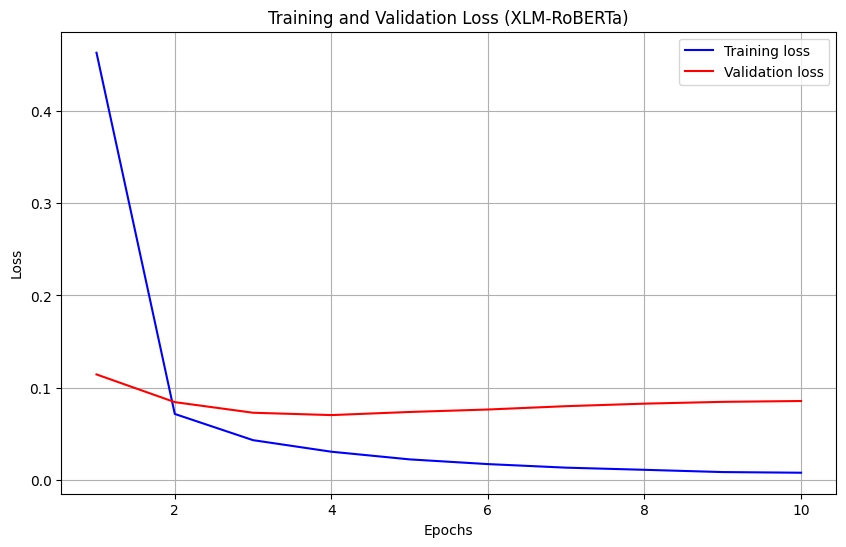

In [23]:
history = trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (XLM-RoBERTa)')

### Evaluate

In [27]:
xlm_roberta_result = evaluate_model(trainer, test_dataset, split_name='test', model_name='XLM-RoBERTa')

Evaluation on test set using XLM-RoBERTa
Classification Report:
                     precision    recall  f1-score   support

                AGE       0.97      0.97      0.97       582
               DATE       0.98      0.99      0.99      1654
             GENDER       0.95      0.98      0.97       462
                JOB       0.70      0.77      0.73       173
           LOCATION       0.94      0.95      0.95      4441
               NAME       0.94      0.96      0.95       318
       ORGANIZATION       0.86      0.89      0.87       771
         PATIENT_ID       0.97      0.99      0.98      2005
SYMPTOM_AND_DISEASE       0.85      0.85      0.85      1136
     TRANSPORTATION       0.95      0.98      0.97       193

          micro avg       0.94      0.95      0.94     11735
          macro avg       0.91      0.93      0.92     11735
       weighted avg       0.94      0.95      0.94     11735

Accuracy: 0.9797
Precision: 0.9358
Recall: 0.9493
F1 Score: 0.9425


### Save model weight

In [25]:
# save model
trainer.save_model('/content/xlm_roberta_ner_final')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]